In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
print(sys.executable)
SRC_SUBDIR = '../..'
SRC_SUBDIR = os.path.abspath(SRC_SUBDIR)
if SRC_SUBDIR not in sys.path:
    print(f'Adding source directory to the sys.path: {SRC_SUBDIR!r}')
    sys.path.insert(1, SRC_SUBDIR)

/opt/homebrew/Caskroom/miniforge/base/envs/nlops/bin/python
Adding source directory to the sys.path: '/Volumes/Data/Projects/NLOperators'


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sir_modelling import simulate_epidemic

In [3]:
Npopulation = 1.0e7
sirmodpars = np.array([0.23, 0.11])
sirdata, tvalues, sirmod = simulate_epidemic(T = 280, dt = 0.1, Tsub=1.0, Npopulation = Npopulation, sir_model = sirmodpars)


{'units': 'days'}


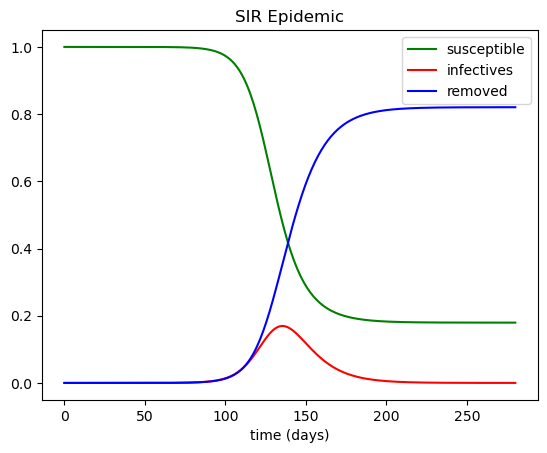

In [4]:
def plot_sirdata(sirdata, tvalues, 
                 data_attributes = [{"linestyle":"-", "label": "susceptible", "color":"g"}, 
                                    {"linestyle":"-", "label": "infectives" , "color":"r"},
                                    {"linestyle":"-", "label": "removed"    , "color":"b"}]):
    
    assert sirdata.shape[0] == len(tvalues)
    assert sirdata.shape[1] == len(data_attributes)
    nticks =11
    M = 1.0e6

    for i, attrs in enumerate(data_attributes):
        plt.plot(tvalues, sirdata[:,i], linestyle=attrs["linestyle"], label=attrs["label"], color=attrs["color"])
        #yticks = np.linspace(0, 1, num=nticks)
        #ylabels = [f"{value / M:.1f} M" for value in yticks] 
        #plt.yticks(yticks, labels=ylabels)
        plt.xlabel("time (days)")
    plt.title("SIR Epidemic")
    plt.legend()

plot_sirdata(sirdata, tvalues)

shape=(4,)
1 : [0.99997927 0.1122277  0.18       0.15      ]
2 : [0.99999532 0.1122295  0.17292694 0.1562034 ]
3 : [1.04446433 0.11224168 0.0533151  0.05114816]
4 : [1.04109402 0.11224114 0.04992071 0.04795297]
5 : [1.26123816 0.1122748  0.03927951 0.03348357]
6 : [1.22891773 0.11226736 0.03310305 0.02589275]
7 : [1.24304174 0.11226746 0.03353951 0.02498095]
8 : [1.14277069 0.1122456  0.03354261 0.02262645]
9 : [1.11641488 0.11223396 0.03577521 0.02340547]
10 : [1.10535553 0.11222615 0.03537231 0.02238152]
11 : [1.11038986 0.11222404 0.03575767 0.02289512]
12 : [1.10950341 0.11221991 0.03574118 0.02287566]
13 : [1.10870835 0.1122097  0.03572557 0.02285455]
14 : [1.10780974 0.11218911 0.03570883 0.02283096]
15 : [1.10662665 0.11214843 0.03568812 0.02280022]
16 : [1.1049277  0.11206802 0.0356605  0.02275658]
17 : [1.10236064 0.11190867 0.03562241 0.02269151]
18 : [1.09837416 0.11159225 0.03556983 0.02259207]
19 : [1.09214743 0.11096485 0.03550034 0.02243979]
20 : [1.08266413 0.10973684 0

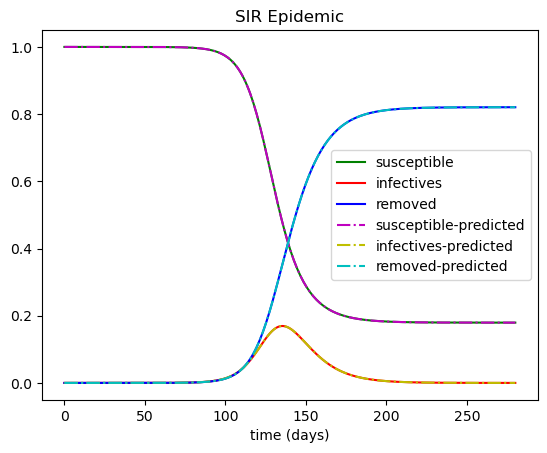

In [12]:
from sir_inversion import SIRInversion, SIRFixedInversion
sirinv = SIRInversion(sirmod=sirmod, data=sirdata)
sirpredicted, params = sirinv(x0 = np.array([1.0, 0.0, 0.18, 0.15]))
data_comparison = np.concatenate([sirdata, sirpredicted], axis=1)
data_attributes = [
    {"linestyle":"-", "label": "susceptible", "color":"g"}, 
    {"linestyle":"-", "label": "infectives" , "color":"r"},
    {"linestyle":"-", "label": "removed"    , "color":"b"},
    {"linestyle":"-.", "label": "susceptible-predicted", "color":"m"}, 
    {"linestyle":"-.", "label": "infectives-predicted" , "color":"y"},
    {"linestyle":"-.", "label": "removed-predicted"    , "color":"c"}
]
plot_sirdata(data_comparison, tvalues,data_attributes)

In [19]:
sirfixedinv = SIRFixedInversion.from_sirmod(sirmod=sirmod, data=sirdata, model0= np.array([0.2,0.1]))
sirfixed, params = sirfixedinv(x0 = np.array([1.0, 0.0]))
print(f"inversion_params = {params}")


shape=(2,)
1 : [1.00000000e+00 2.34164558e-08]
2 : [1.20127766e+00 2.34189400e-08]
3 : [1.14556967e+00 2.34183098e-08]
4 : [1.14976107e+00 2.34184204e-08]
5 : [1.14951223e+00 2.34184770e-08]
6 : [1.14940883e+00 2.34188418e-08]
7 : [1.14932671e+00 2.34195532e-08]
8 : [1.14886022e+00 2.34263252e-08]
9 : [1.14834859e+00 2.34392007e-08]
10 : [1.14780721e+00 2.34613425e-08]
11 : [1.14716034e+00 2.35002770e-08]
12 : [1.14629674e+00 2.35712079e-08]
13 : [1.14505419e+00 2.37036256e-08]
14 : [1.14318229e+00 2.39544667e-08]
15 : [1.14029924e+00 2.44326817e-08]
16 : [1.13588122e+00 2.53402723e-08]
17 : [1.12944433e+00 2.70163883e-08]
18 : [1.12124164e+00 2.98911223e-08]
19 : [1.11272312e+00 3.43472089e-08]
20 : [1.10512754e+00 4.11454084e-08]
21 : [1.09940838e+00 5.23567755e-08]
22 : [1.09645499e+00 7.40510003e-08]
23 : [1.09389263e+00 1.00091030e-07]
24 : [1.08604686e+00 1.37614839e-07]
25 : [1.07152482e+00 1.95316817e-07]
26 : [1.05651200e+00 2.68033453e-07]
27 : [1.04694391e+00 3.43604460e-07]

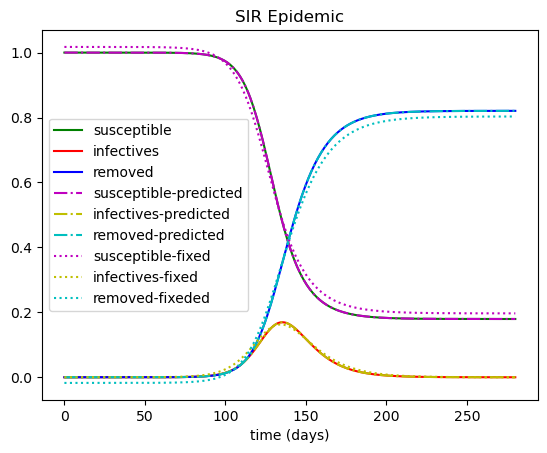

In [ ]:
data_comparison = np.concatenate([sirdata, sirpredicted, sirfixed], axis=1)
data_attributes = [
    {"linestyle":"-", "label": "susceptible", "color":"g"}, 
    {"linestyle":"-", "label": "infectives" , "color":"r"},
    {"linestyle":"-", "label": "removed"    , "color":"b"},
    {"linestyle":"-.", "label": "susceptible-predicted", "color":"m"}, 
    {"linestyle":"-.", "label": "infectives-predicted" , "color":"y"},
    {"linestyle":"-.", "label": "removed-predicted"    , "color":"c"},
    {"linestyle":":", "label": "susceptible-fixed", "color":"m"}, 
    {"linestyle":":", "label": "infectives-fixed" , "color":"y"},
    {"linestyle":":", "label": "removed-fixed"    , "color":"c"}
]
plot_sirdata(data_comparison, tvalues,data_attributes)

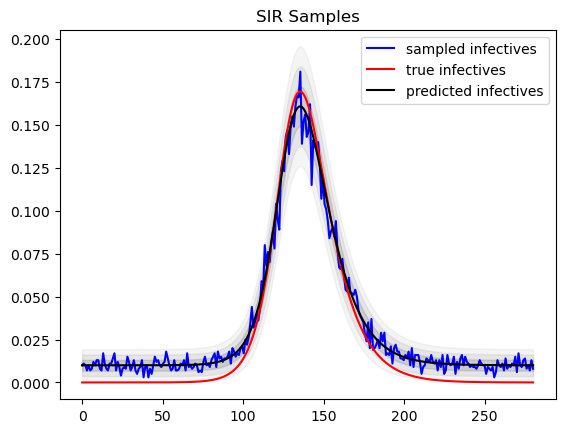

In [22]:
from sir_modelling import sample
nsamples = 1000
ptp = 0.9
pfp = 0.01
infectives = sirdata[:, 1]
positives = sample(infectives, ptp, pfp, nsamples)
fractions = positives/nsamples
sir_sample_mod = sirmod.create_sampler()
predicted = ptp*infectives + pfp*(1-infectives)
std = np.sqrt(predicted*(1-predicted)/nsamples)
plt.plot(tvalues, fractions, label="sampled infectives", color="blue")
plt.plot(tvalues, infectives, label="true infectives", color="red")
plt.plot(tvalues, predicted, label="predicted infectives", color="black")
for mult in range(1,4):
    plt.fill_between(tvalues, predicted - mult*std, predicted + mult*std, color="grey", alpha=0.25/mult)
plt.title("SIR Samples")
plt.legend()


In [23]:
from src.operators.base import check_dot_product, check_linearization
test_input = np.array([0.9, 0.1, 0.21, 0.11, 0.9, 0.1])
check_linearization(sir_sample_mod, test_input)
check_dot_product(sir_sample_mod, test_input)

shape=(6,)
1 : [1.00000000e+00 1.24047838e-02 1.80000000e-01 1.50000000e-01
 1.00000000e+00 5.82735157e-05]
2 : [0.99984088 0.01239496 0.17881942 0.15049781 1.00000409 0.00832932]
3 : [0.99449198 0.01240515 0.14850925 0.17997253 0.99915681 0.01672076]
4 : [0.9936761  0.01237607 0.21220278 0.28309447 0.98997556 0.033546  ]
5 : [0.99183991 0.0123755  0.21127413 0.28367854 0.98645429 0.03319217]
6 : [0.98757665 0.01237323 0.21108298 0.28816539 0.97791222 0.03288657]
7 : [0.97829666 0.01236742 0.21218407 0.30021296 0.95878214 0.03261944]
8 : [0.95733171 0.01235305 0.2165728  0.33006674 0.91457384 0.03251365]
9 : [0.92735418 0.01233139 0.22437586 0.37470189 0.85025133 0.03275951]
10 : [0.88767781 0.01230224 0.23490683 0.4337624  0.76406853 0.03313131]
11 : [0.83670037 0.01226482 0.24765245 0.50823464 0.6523787  0.03339531]
12 : [0.76901429 0.01221534 0.26360014 0.60551193 0.50324117 0.03348437]
13 : [0.67632931 0.01214778 0.28476874 0.73765764 0.29832107 0.03342934]
14 : [0.55295653 0.01205

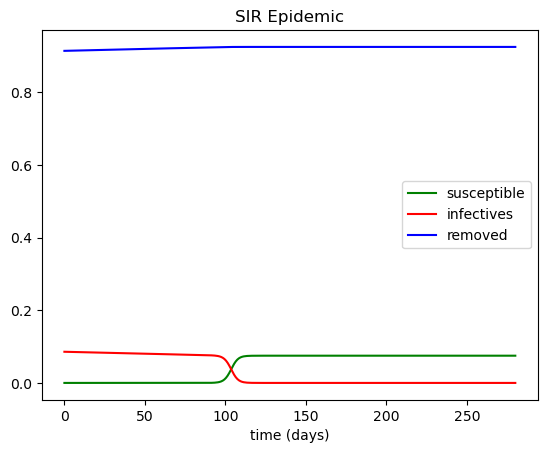

In [28]:
from sir_inversion import SIRInversion
sirinv = SIRInversion(sirmod=sir_sample_mod, data=fractions[:,np.newaxis])
predicted, params = sirinv(x0 = np.array([1.0, 0.0, 0.18, 0.15, 1.0, 0.0]))
print(params)
print(predicted.shape)
plot_sirdata(predicted, tvalues)